# **Convex Optimization Project 2**
Name: Reza Kahidi\
Student Number: 810101249

In [6]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Data

In [7]:
Q = 15  # Battery capacity in GW
C = 15 / 4  # Maximum charge/discharge rate in GW
a = 0.1  # Coefficient for linear term in quadratic cost function in $10^6/GW
b = 0.005  # Coefficient for quadratic term in quadratic cost function in $10^6/GW^2

l = np.asarray(
    [21.34191954, 21.18082759, 20.96743678, 20.76724138, 20.60328736,
     20.47901149, 20.33221839, 20.20188506, 20.1091954, 20.06005747,
     19.98218391, 19.91656322, 19.91108046, 19.92598851, 19.9263908,
     19.95235632, 20.07229885, 20.25916092, 20.40158621, 20.57654023,
     20.91581609, 21.30312644, 21.59070115, 21.91572414, 22.44517241,
     22.96125287, 23.23689655, 23.47072414, 23.7072069, 23.9123908,
     23.9323908, 23.89454023, 23.84212644, 23.7435977, 23.47114943,
     23.17532184, 22.94258621, 22.71243678, 22.38668966, 22.08251724,
     21.80866667, 21.53998851, 21.2727931, 21.03797701, 20.8167931,
     20.62733333, 20.46255172, 20.29644828, 20.13751724, 20.0298046,
     19.91989655, 19.83633333, 19.75285057, 19.72950575, 19.70543678,
     19.72454023, 19.72749425, 19.75965517, 19.81554023, 19.93401149,
     20.05833333, 20.22910345, 20.43187356, 20.68208046, 20.89424138,
     21.20185057, 21.58913793, 22.02983908, 22.41070115, 22.85716092,
     23.38570115, 23.94273563, 24.44466667, 24.87712644, 25.19521839,
     25.44010345, 25.65931034, 25.90294253, 26.06342529, 26.07808046,
     25.96606897, 25.814, 25.63070115, 25.41873563, 25.21206897,
     25.02482759, 24.75267816, 24.44406897, 24.0662069, 23.6843908,
     23.31312644, 22.94794253, 22.58410345, 22.2401954, 21.91117241,
     21.60796552])

s = np.asarray(
    [-0.03617241, -0.03613793, -0.03657471, -0.03378161, -0.03536782,
     -0.03536782, -0.03535632, -0.03531034, -0.03547126, -0.03557471,
     -0.03565517, -0.03601149, -0.03644828, -0.03697701, -0.03742529,
     -0.03809195, -0.03837931, -0.03843678, -0.03847126, -0.03865517,
     -0.03906897, -0.03950575, -0.03977011, -0.03964368, -0.03295402,
        0.03156322,  0.24817241,  0.68012644,  1.34516092,  2.34498851,
        3.58345977,  4.82156322,  6.09688506,  7.20993103,  8.09786207,
        8.61782759,  9.16962069,  9.63973563,  9.79171264,  9.92125287,
     10.1645977, 10.23402299, 10.20718391, 10.16213793, 10.15095402,
     10.08826437, 10.09511494, 10.00224138,  9.96237931,  9.94972414,
        9.90524138,  9.85172414,  9.79181609,  9.75329885,  9.64002299,
        9.5753908,  9.47358621,  9.32724138,  9.27497701,  9.19827586,
        9.04288506,  8.85916092,  8.64457471,  8.42649425,  7.93597701,
        7.36075862,  6.97835632,  6.30435632,  5.39842529,  4.571,
        3.81128736,  2.97521839,  2.09649425,  1.31252874,  0.66016092,
        0.23991954,  0.04734483, -0.02125287, -0.03608046, -0.03522989,
     -0.03489655, -0.03495402, -0.03574713, -0.03547126, -0.03489655,
     -0.03428736, -0.03433333, -0.03434483, -0.03445977, -0.03554023,
     -0.03548276, -0.03541379, -0.0356092, -0.03498851, -0.03567816,
     -0.03563218])

n = l - s
""""
# Below is the code to generate data from its source CAISO
# You will need to install the CAISO package to run this code
# pip install gridstatus
import gridstatus
import pandas as pd
start = pd.Timestamp("March 1, 2021").normalize()
end = pd.Timestamp("March 31, 2021").normalize()
load_data = caiso.get_load(start, end=end)
load_data_15_minute = load_data.set_index("Time").resample("15T").mean()
load = load_data_15_minute.groupby(load_data_15_minute.index.time).mean()
fuel_mixture_data = caiso.get_fuel_mix(start, end=end, verbose=False)
fuel_mixture_data_15_minute = fuel_mixture_data .set_index("Time").resample("15T").mean()
solar = fuel_mixture_data_15_minute.groupby(fuel_mixture_data_15_minute.index.time).mean()
# Combine load and solar into a single dataframe
combined_df = pd.DataFrame({'Load': load['Load'],'Solar': solar['Solar']})
combined_df['Net_load'] = combined_df['Load'] - combined_df['Solar']
# Convert to numpy arrays and adjust for GW
l = combined_df['Load'].to_numpy()*0.001
n = combined_df['Net_load'].to_numpy()*0.001
s = combined_df['Solar'].to_numpy()*0.001
"""


'"\n# Below is the code to generate data from its source CAISO\n# You will need to install the CAISO package to run this code\n# pip install gridstatus\nimport gridstatus\nimport pandas as pd\nstart = pd.Timestamp("March 1, 2021").normalize()\nend = pd.Timestamp("March 31, 2021").normalize()\nload_data = caiso.get_load(start, end=end)\nload_data_15_minute = load_data.set_index("Time").resample("15T").mean()\nload = load_data_15_minute.groupby(load_data_15_minute.index.time).mean()\nfuel_mixture_data = caiso.get_fuel_mix(start, end=end, verbose=False)\nfuel_mixture_data_15_minute = fuel_mixture_data .set_index("Time").resample("15T").mean()\nsolar = fuel_mixture_data_15_minute.groupby(fuel_mixture_data_15_minute.index.time).mean()\n# Combine load and solar into a single dataframe\ncombined_df = pd.DataFrame({\'Load\': load[\'Load\'],\'Solar\': solar[\'Solar\']})\ncombined_df[\'Net_load\'] = combined_df[\'Load\'] - combined_df[\'Solar\']\n# Convert to numpy arrays and adjust for GW\nl = 

# Problem

In [8]:
# Define optimization variables
q = cp.Variable((96, 1))
c = cp.Variable((96, 1))
g = cp.Variable((96, 1))
n = n.reshape((96, 1))

# Define objective function
objective = cp.Minimize(cp.sum(a * g + b * cp.square(g)))

max_ramp_no_storage = 4 * max(np.linalg.norm(np.diff(n, axis=0), ord=np.inf), np.linalg.norm(n[0] - n[-1], ord=1)) # Max ramp rate without storage
max_ramp_target = 0.5 * max_ramp_no_storage   # Target max ramp rate with storage

J = 4 * cp.maximum(cp.norm(cp.diff(g, axis=0),"inf"), cp.norm(g[0] - g[-1], 1))

# Define constraints
constraints = [
    g == n + c,
    cp.diff(q) == 0.25 * c[:-1],
    q[0] == q[-1] + 0.25 * c[-1],
    0 <= q, q <= Q,
    cp.abs(c) <= C,
    J <= max_ramp_target
]

# Formulate and solve the problem
prob = cp.Problem(objective, constraints)
prob.solve()
print(prob.status)
print(prob.value)

# Extract optimal values
optimal_cost = prob.value
optimal_generation = g.value
optimal_charging = c.value
optimal_storage = q.value
max_ramp_with_storage = 4 * max(np.linalg.norm(np.diff(optimal_generation, axis=0), ord=np.inf), np.linalg.norm(optimal_generation[0] - optimal_generation[-1], ord=1))





optimal
343.723910148846


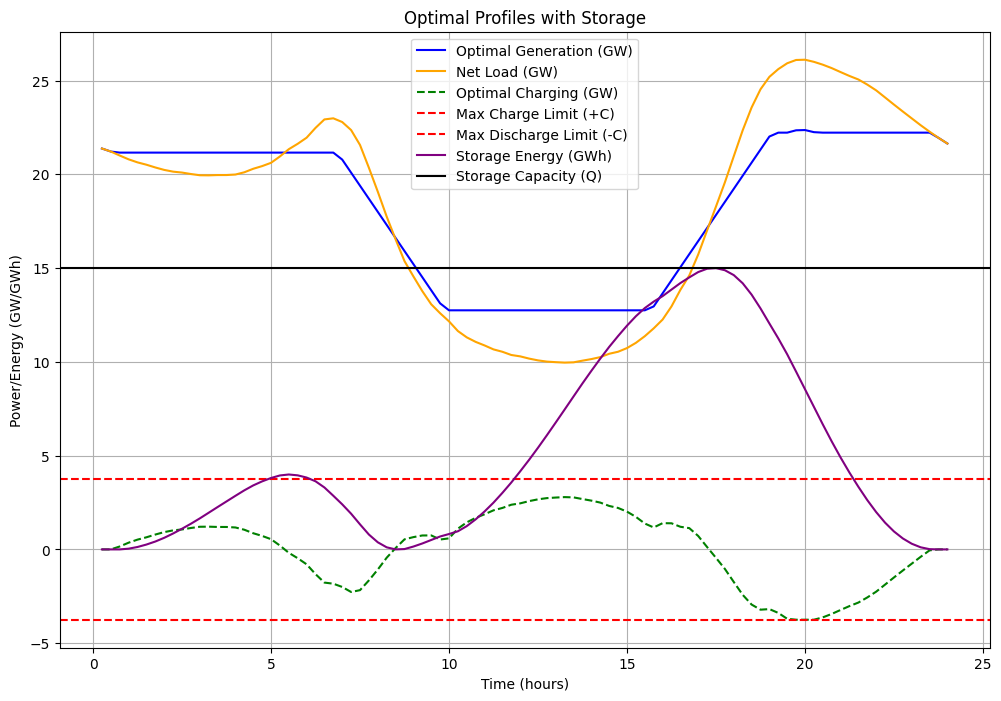

Optimal Cost: $343.72

Maximum Ramp Rate without Storage: 5.57 GW/h 

Maximum Ramp Rate with Storage: 2.79 GW/h 



In [14]:
# Plotting
time = np.arange(1, 97) * 0.25  # Time intervals in hours

plt.figure(figsize=(12, 8))

# Plot optimal generation and net load
plt.plot(time, optimal_generation, label='Optimal Generation (GW)', color='blue')
plt.plot(time, n.flatten(), label='Net Load (GW)', color='orange')

# Plot optimal charging with charge limits
plt.plot(time, optimal_charging, label='Optimal Charging (GW)', linestyle='--', color='green')
plt.axhline(y=C, color='red', linestyle='--', label='Max Charge Limit (+C)')
plt.axhline(y=-C, color='red', linestyle='--', label='Max Discharge Limit (-C)')

# Plot storage energy with capacity limit
plt.plot(time, optimal_storage, label='Storage Energy (GWh)', linestyle='-', color='purple')
plt.axhline(y=Q, color='black', linestyle='-', label='Storage Capacity (Q)')

# Add labels and legend
plt.xlabel('Time (hours)')
plt.ylabel('Power/Energy (GW/GWh)')
plt.title('Optimal Profiles with Storage')
plt.legend()

# Show plot
plt.grid(True)
plt.show()

# Print results
print(f'Optimal Cost: ${optimal_cost:.2f}\n')
print(f'Maximum Ramp Rate without Storage: {max_ramp_no_storage:.2f} GW/h \n')
print(f'Maximum Ramp Rate with Storage: {max_ramp_with_storage:.2f} GW/h \n')


In [12]:
print("Optimal Storage: \n", q.value)
print("\n ----------------------------------------")
print("Optimal Generation: \n", g.value)
print("\n ----------------------------------------")
print("Optimal Charge: \n", c.value)
print("\n ----------------------------------------")

Optimal Storage: 
 [[-8.43916329e-10]
 [-3.92564908e-08]
 [ 1.80117483e-06]
 [ 3.89521049e-02]
 [ 1.28649776e-01]
 [ 2.58939427e-01]
 [ 4.20298087e-01]
 [ 6.18357951e-01]
 [ 8.49012713e-01]
 [ 1.10279974e+00]
 [ 1.36884549e+00]
 [ 1.65433962e+00]
 [ 1.95614996e+00]
 [ 2.25922194e+00]
 [ 2.55843488e+00]
 [ 2.85743533e+00]
 [ 3.14977792e+00]
 [ 3.41206323e+00]
 [ 3.62761887e+00]
 [ 3.80755977e+00]
 [ 3.94371643e+00]
 [ 3.99495092e+00]
 [ 3.94924889e+00]
 [ 3.83158737e+00]
 [ 3.63270199e+00]
 [ 3.30312726e+00]
 [ 2.86066204e+00]
 [ 2.40343676e+00]
 [ 1.90273639e+00]
 [ 1.33495318e+00]
 [ 7.91608635e-01]
 [ 3.78658413e-01]
 [ 1.10472229e-01]
 [-5.23313051e-06]
 [ 1.81853303e-02]
 [ 1.52245533e-01]
 [ 3.16029542e-01]
 [ 5.01722242e-01]
 [ 6.88258774e-01]
 [ 8.20005566e-01]
 [ 9.67172811e-01]
 [ 1.24363736e+00]
 [ 1.60462797e+00]
 [ 2.02570783e+00]
 [ 2.49423034e+00]
 [ 3.01525296e+00]
 [ 3.56796819e+00]
 [ 4.16359150e+00]
 [ 4.77752231e+00]
 [ 5.42122035e+00]
 [ 6.08868272e+00]
 [ 6.7725013